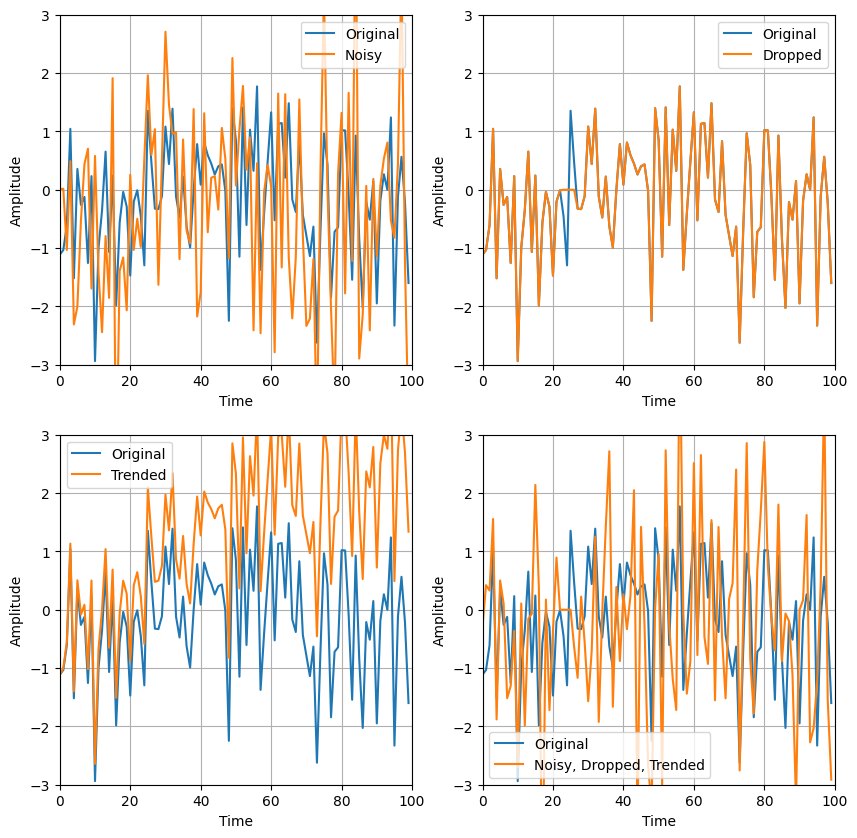

In [7]:
# a notebook to test the augmentation functions and visualize the results before and after augmentation
from astfnet.data_io.augmentation import AddRandomNoise, DropRegion, AddTrend
import torch
import matplotlib.pyplot as plt
from speechbrain.augment.augmenter import Augmenter

# create a waveform
waveform = torch.randn(1,100)

augmenter = Augmenter(augmentations=[AddRandomNoise(noise_level=0.5), DropRegion(max_drop_length=10), AddTrend(min_deg=-2, max_deg=2)])
noisy_waveform = AddRandomNoise(noise_level=0.5)(waveform)
dropped_waveform = DropRegion(max_drop_length=10)(waveform)
trended_waveform = AddTrend(min_deg=-2, max_deg=2)(waveform)
augmented_waveform, _ = augmenter(waveform, lengths=torch.tensor([1.0]))

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for ax in axs.flat:
    ax.plot(waveform[0], label='Original')
axs[0, 0].plot(noisy_waveform[0], label='Noisy')
axs[0, 1].plot(dropped_waveform[0], label='Dropped')
axs[1, 0].plot(trended_waveform[0], label='Trended')
axs[1, 1].plot(augmented_waveform[0], label='Noisy, Dropped, Trended')

axs[0, 0].legend()
axs[0, 1].legend()
axs[1, 0].legend()
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
    ax.set_xlim(0, 100)
    ax.set_ylim(-3, 3)
plt.show()